<font size="6">Demo of Overlapping Areas</font>

First we import some packages

In [1]:
import numpy as np
import pyPolygon as pp
from matplotlib import pyplot as plt

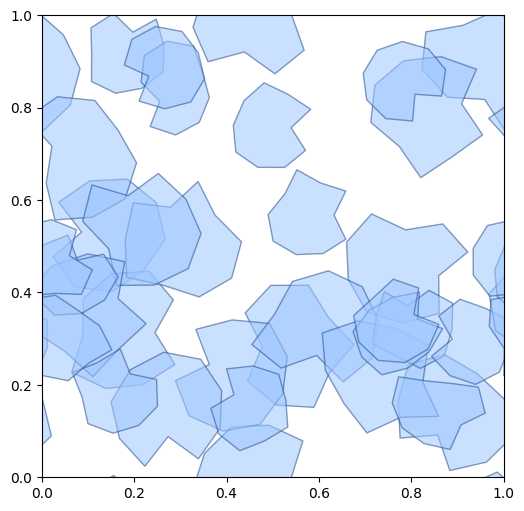

In [2]:
packing = pp.Model(N = 32, n = 10, seed = 42)
packing.generateEquilateralPolygons(phi = 1.0, kappa = 4.0)
packing.setBiPerimeter() # first half small. second half large. default ratio 1.4
packing.draw()
plt.show()

Next we need to set the spring constants for the various energy terms.
Let's start out with no adhesion (actually at the time of me writing this, I haven't implemented the adhesion part yet). The default is for the area and perimeter springs to have a spring constant of 1 and the overlap spring is always 1 as it sets the overall scale.

packing.setSpringConstants(adhesion = 0, area = 1, perimeter = 1)

In [3]:
packing.setSpringConstants(0, area = 1, perimeter = 1, edge = 1)

We want to set the mollification parameter, sigma

In [5]:
packing.updateEnergyParallel()
packing.updateForcesParallel()

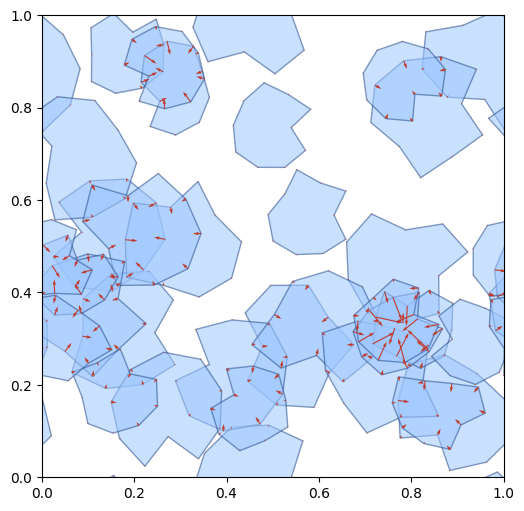

In [6]:
packing.draw(forces = packing.getForces())
plt.show()

FIRE:   0%|          | 0/1000 [00:00<?, ?it/s]

<Axes: >

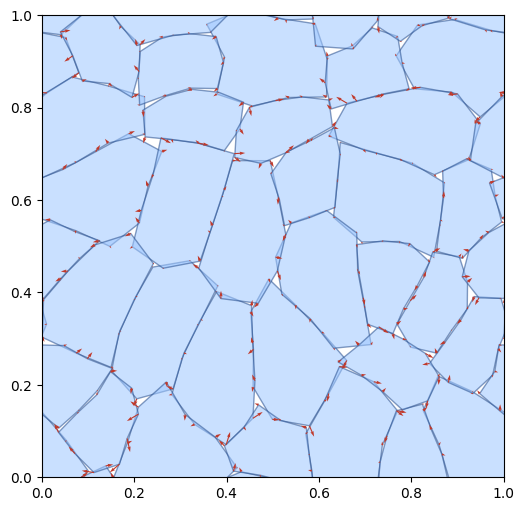

In [7]:
energy, steps, converged = packing.minimizeFIRE(maxSteps = 1_000, fThreshold = 1e-3)
packing.draw(forces = packing.getForces())

In [11]:
packing.minimizeNewton("1e-14")
packing.draw(forces = packing.getForces())

TypeError: '<' not supported between instances of 'float' and 'str'

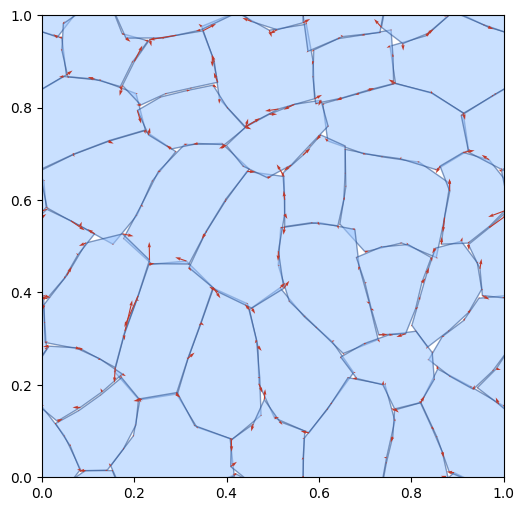

In [9]:
packing.draw(forces = packing.getForces())
plt.show()

In [10]:
np.max(np.abs(packing.getForces()))

0.0006114438675544828